# Car Price Prediction with Machine Learning
**CodeAlpha Data Science Internship — Task 3**

Goal: Predict the resale (selling) price of a used car based on features like
present price, kilometers driven, fuel type, seller type, transmission, owner history, and car age.


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Dataset

In [5]:
df = pd.read_csv(r"C:\Users\MOUNIKA\Downloads\archive (10)\car data.csv")
print("Shape:", df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Explore the Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
for col in ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']:
    print(col, ":", df[col].unique())

Fuel_Type : ['Petrol' 'Diesel' 'CNG']
Selling_type : ['Dealer' 'Individual']
Transmission : ['Manual' 'Automatic']
Owner : [0 1 3]


## 4. Feature Engineering
- Convert `Year` into `Car_Age` (more directly meaningful for price).
- Drop `Car_Name` since it has too many unique values for a dataset this size.
- Keep `Fuel_Type`, `Selling_type`, `Transmission` as categorical columns; they get
  one-hot encoded automatically inside the pipeline below, so the same preprocessing
  is applied consistently to both training and test data (and to any new data later).

In [10]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']
df.drop(['Year', 'Car_Name'], axis=1, inplace=True)
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 5. Exploratory Data Analysis

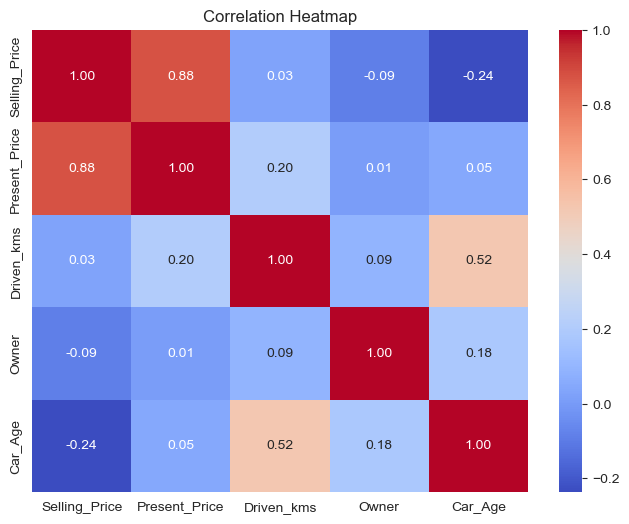

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

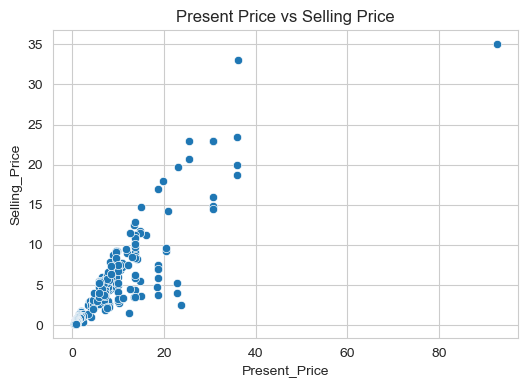

In [12]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title("Present Price vs Selling Price")
plt.show()

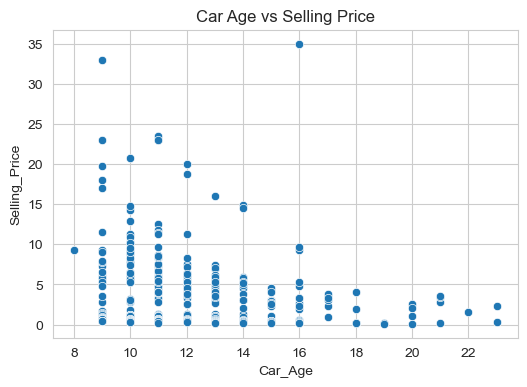

In [13]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title("Car Age vs Selling Price")
plt.show()

Present_Price usually shows the strongest positive correlation with Selling_Price, while Car_Age and Driven_kms tend to correlate negatively — older, more-driven cars sell for less.

## 6. Train-Test Split and Preprocessing Pipeline
Categorical columns (`Fuel_Type`, `Selling_type`, `Transmission`) are one-hot encoded
inside a `ColumnTransformer`, wrapped in a `Pipeline` together with the model. This
keeps preprocessing and modeling as a single reproducible unit and avoids data leakage.

In [14]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical_cols)],
    remainder='passthrough'
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (240, 7) Test shape: (61, 7)


## 7. Model 1: Linear Regression

In [15]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

## 8. Model 1 Evaluation
Evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [16]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression Results
MAE: 1.2163740193324302
RMSE: 1.8658375680932118
R2 Score: 0.8488707839194816


## 9. Model 2: Random Forest Regression
An ensemble method that combines multiple decision trees to capture non-linear
relationships between car features and selling price.

In [17]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## 10. Model 2 Evaluation

In [18]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 0.6423655737704909
RMSE: 0.9792008038090689
R2 Score: 0.9583759546741363


## 11. Model Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.216374,1.865838,0.848871
1,Random Forest,0.642366,0.979201,0.958376


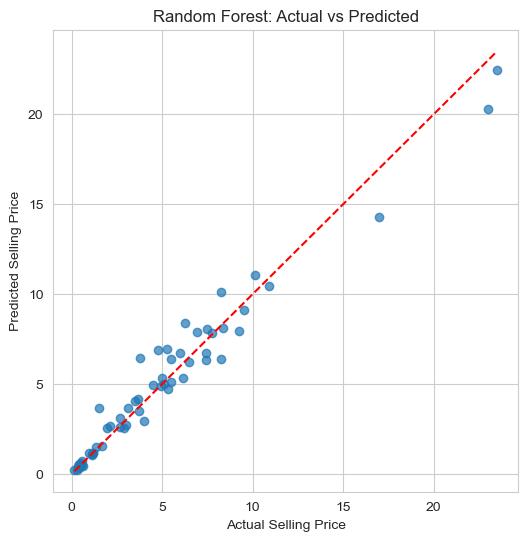

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

## 12. Feature Importance (Random Forest)

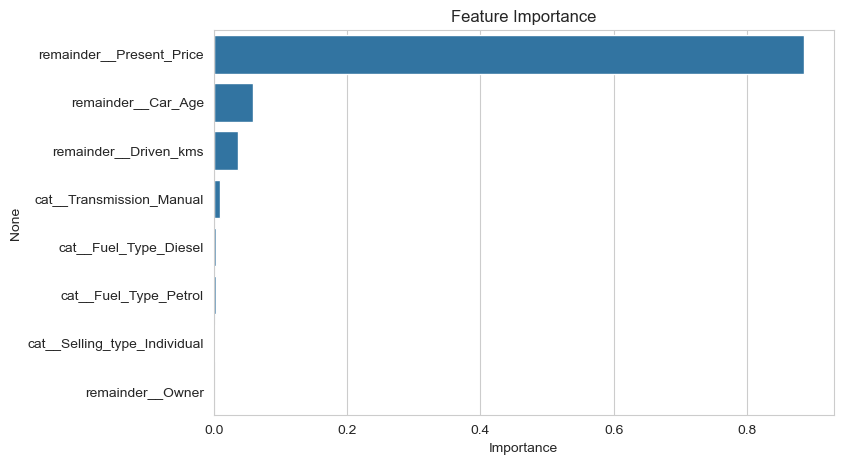

remainder__Present_Price        0.886061
remainder__Car_Age              0.058797
remainder__Driven_kms           0.036971
cat__Transmission_Manual        0.008784
cat__Fuel_Type_Diesel           0.003963
cat__Fuel_Type_Petrol           0.002602
cat__Selling_type_Individual    0.002150
remainder__Owner                0.000672
dtype: float64

In [21]:
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(
    rf_model.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

importances

## 13. Conclusion

- **Present_Price** and **Car_Age** are the strongest predictors of a used car's selling price.
- **Random Forest** outperforms Linear Regression, since price does not scale purely linearly with these features.
- Business takeaway: cars with a lower present-day showroom reference price, higher age, and higher kilometers driven sell for noticeably less — this model can be used to sanity-check a fair resale price.

### Possible next steps
- Try `GradientBoostingRegressor` or `XGBoost` for potentially better accuracy.
- Use `GridSearchCV` to tune Random Forest hyperparameters (`n_estimators`, `max_depth`, etc.).
- Engineer a feature from `Car_Name` (e.g., extract brand) instead of dropping it entirely.
